# Movie Recommendation System - Kaggle Recommender Project

This project builds a production-ready movie recommendation model for the Kaggle Movie Recommendation Hackathon. The goal is to predict how a user would rate a movie, then use those predicted ratings to recommend movies that a user is likely to enjoy.

The problem is a classic recommender-system task: given historical user-movie ratings, learn patterns about user preferences, movie popularity, genre/content signals, and collaborative behavior. The final solution combines several model families: simple baselines, regularized user/movie bias models, matrix factorization, content-based genome-tag features, an optimized ensemble, and a LightGBM stacking model.

The main business question being solved is: **which movies should be recommended to a user when we only know past ratings from many users and metadata about the movies?**


In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/movie-recommendation-hackathon-2026/sample_submission.csv
/kaggle/input/competitions/movie-recommendation-hackathon-2026/movies.csv
/kaggle/input/competitions/movie-recommendation-hackathon-2026/imdb_data.csv
/kaggle/input/competitions/movie-recommendation-hackathon-2026/genome_tags.csv
/kaggle/input/competitions/movie-recommendation-hackathon-2026/genome_scores.csv
/kaggle/input/competitions/movie-recommendation-hackathon-2026/train.csv
/kaggle/input/competitions/movie-recommendation-hackathon-2026/test.csv
/kaggle/input/competitions/movie-recommendation-hackathon-2026/tags.csv
/kaggle/input/competitions/movie-recommendation-hackathon-2026/links.csv


## Stage 1 - Environment Setup and Data Location

This stage prepares the notebook to run both on Kaggle and locally. It imports the main data-science libraries, configures plotting, and automatically finds the competition data folder.

What was learned:
- Kaggle notebooks have a different file structure from a local machine.
- A robust project should detect its data path instead of hard-coding one location.
- Large recommender datasets require memory-aware workflows from the start.


In [2]:
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy.sparse import csr_matrix
from scipy.optimize import minimize
from sklearn.decomposition import TruncatedSVD
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error
from numba import njit

%matplotlib inline
plt.rcParams['figure.figsize'] = (8, 4)
plt.rcParams['axes.grid'] = True
pd.set_option('display.max_columns', 50)

# Auto-find train.csv under /kaggle/input when running on Kaggle; otherwise fall back to
# a local "data" folder next to this notebook (and write outputs to a local "working" folder).
_kaggle_hits = list(Path('/kaggle/input').rglob('train.csv')) if Path('/kaggle/input').exists() else []
if _kaggle_hits:
    DATA_DIR   = _kaggle_hits[0].parent
    OUTPUT_DIR = Path('/kaggle/working')          # writable; preserved on "Save & Run All"
else:
    DATA_DIR   = Path('data')
    OUTPUT_DIR = Path('working')
    OUTPUT_DIR.mkdir(exist_ok=True)

print('DATA_DIR :', DATA_DIR)
print('Files    :', sorted(f.name for f in DATA_DIR.glob('*.csv')))

DATA_DIR : /kaggle/input/competitions/movie-recommendation-hackathon-2026
Files    : ['genome_scores.csv', 'genome_tags.csv', 'imdb_data.csv', 'links.csv', 'movies.csv', 'sample_submission.csv', 'tags.csv', 'test.csv', 'train.csv']


## Stage 2 - Data Loading and Memory-Aware Types

The core files are loaded: training ratings, test pairs, movie metadata, and the sample submission. Rating data is loaded with smaller numeric dtypes to reduce memory usage.

What was learned:
- Recommender datasets can be too large for casual loading if data types are not controlled.
- `userId`, `movieId`, and `rating` are the core columns for collaborative filtering.
- The test set contains user/movie pairs where the model must predict ratings.


In [3]:
# Create an optimized rating data types
rating_dtypes = {'userId': 'int32', 'movieId': 'int32', 'rating': 'float32'}

# Load the core datasets with the optimized data types
train = pd.read_csv(DATA_DIR / 'train.csv', dtype=rating_dtypes)
test = pd.read_csv(DATA_DIR / 'test.csv', dtype=rating_dtypes)
movies = pd.read_csv(DATA_DIR / 'movies.csv')
sample = pd.read_csv(DATA_DIR / 'sample_submission.csv')

# Print the shape of the datasets
print('*' * 40)
print('Train shape:', train.shape)
print('Test shape:', test.shape)
print('Movies shape:', movies.shape)
print('Sample shape:', sample.shape)

****************************************
Train shape: (10000038, 4)
Test shape: (5000019, 2)
Movies shape: (62423, 3)
Sample shape: (5000019, 2)


In [4]:
display(train.head())
display(test.head())
display(movies.head())
display(sample.head())

,userId,movieId,rating,timestamp
0,5163,57669,4.0,1518349992
1,106343,5,4.5,1206238739
2,146790,5459,5.0,1076215539
3,106362,32296,2.0,1423042565
4,9041,366,3.0,833375837


,userId,movieId
0,1,2011
1,1,4144
2,1,5767
3,1,6711
4,1,7318


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


,Id,rating
0,1_2011,1.0
1,1_4144,1.0
2,1_5767,1.0
3,1_6711,1.0
4,1_7318,1.0


## Stage 3 - Basic Data Audit

Before modeling, the notebook inspects example rows, data types, summary statistics, and missing values. This confirms whether the tables loaded correctly and whether cleaning is needed.

What was learned:
- A model is only as reliable as the assumptions made about the input data.
- Checking missing values and data types early prevents silent errors later.
- Large-scale recommendation projects need simple validation checks before complex modeling.


In [5]:
display(train.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000038 entries, 0 to 10000037
Data columns (total 4 columns):
 #   Column     Dtype  
---  ------     -----  
 0   userId     int32  
 1   movieId    int32  
 2   rating     float32
 3   timestamp  int64  
dtypes: float32(1), int32(2), int64(1)
memory usage: 190.7 MB


None

In [6]:
# Check if there are missing values in each feature of the datasets
print('Missing values in train data:')
for name, df in [('train', train), ('test', test), ('movies', movies), ('sample', sample)]:
    print(f'{name}:', df.isnull().sum().to_dict())

Missing values in train data:
train: {'userId': 0, 'movieId': 0, 'rating': 0, 'timestamp': 0}
test: {'userId': 0, 'movieId': 0}
movies: {'movieId': 0, 'title': 0, 'genres': 0}
sample: {'Id': 0, 'rating': 0}


## Stage 4 - Understanding the Target Variable

This stage studies the distribution of movie ratings. It establishes the prediction target and helps explain why RMSE is an appropriate evaluation metric for this competition.

What was learned:
- Ratings are bounded values, usually between 0.5 and 5.0.
- The global average rating is a useful first benchmark.
- Evaluation should compare every advanced model against a simple baseline.


Global mean :  4


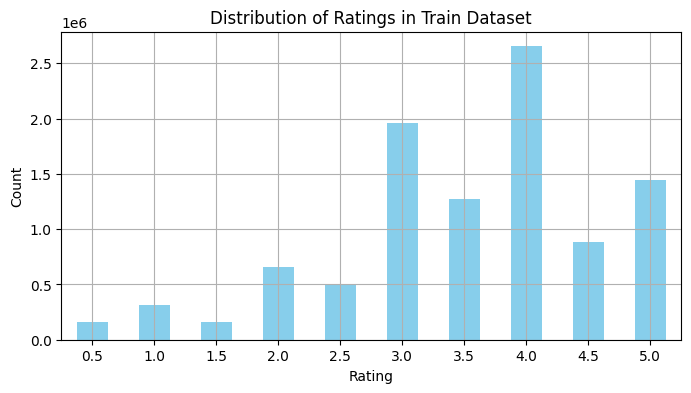

In [7]:
# Compute the global mean
print('Global mean : ', round(train['rating'].mean()))

# Compute the count of rating
counts = train['rating'].value_counts().sort_index()

# Plot the distribution

ax = counts.plot.bar(color='skyblue')
ax.set_xlabel('Rating')
ax.set_ylabel('Count')
ax.set_title('Distribution of Ratings in Train Dataset')
plt.xticks(rotation=0)
plt.show()

## Stage 5 - User and Movie Activity Analysis

The notebook measures how many ratings each user and movie has. This reveals popularity patterns and sparsity: most users rate only a small subset of movies, and many movies receive fewer ratings than popular titles.

What was learned:
- Recommender systems are sparse by nature.
- Popular movies and active users are easier to model than rare movies and inactive users.
- Cold-start behavior must be considered because some user/movie pairs may have little historical signal.


Ratings per user statistics: {'min': 1.0, '50%': 28.0, 'mean': 61.52, 'max': 12952.0}

Ratings per movie statistics: {'min': 1.0, '50%': 4.0, 'mean': 207.41, 'max': 32831.0}


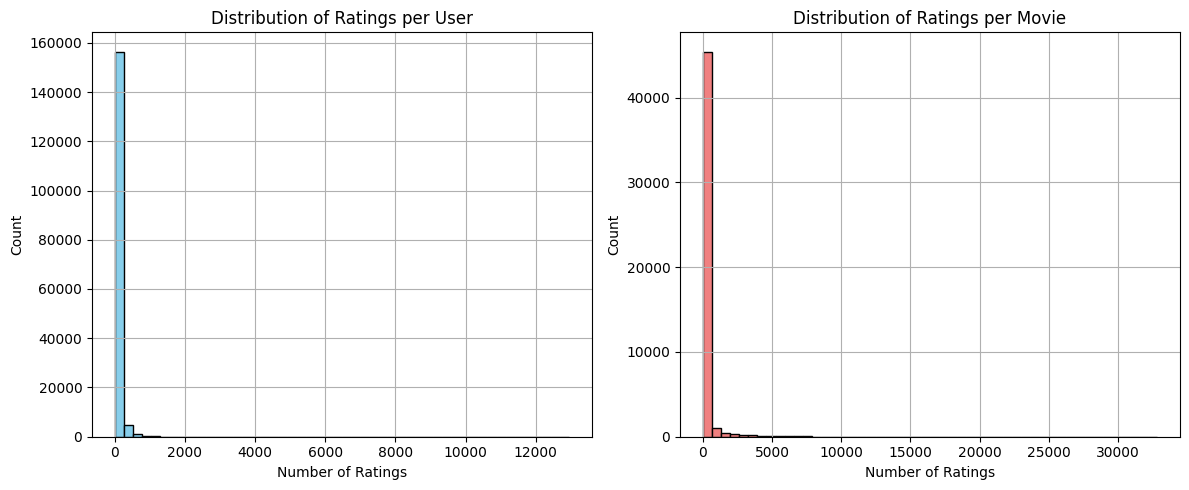

In [8]:
# Get active users and movies
ratings_per_user = train.groupby('userId').size()
ratings_per_movie = train.groupby('movieId').size()

# print the statistics for ratings per user and per movie
print("Ratings per user statistics:", ratings_per_user.describe()[['min', '50%', 'mean', 'max']].round(2).to_dict())

print("\nRatings per movie statistics:", ratings_per_movie.describe()[['min', '50%', 'mean', 'max']].round(2).to_dict())


# Plot the distribution of ratings per user and per movie
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].hist(ratings_per_user, bins=50, color='skyblue', edgecolor='black')
axes[0].set_title('Distribution of Ratings per User')
axes[0].set_xlabel('Number of Ratings')
axes[0].set_ylabel('Count')

axes[1].hist(ratings_per_movie, bins=50, color='lightcoral', edgecolor='black')
axes[1].set_title('Distribution of Ratings per Movie')
axes[1].set_xlabel('Number of Ratings')
axes[1].set_ylabel('Count')
plt.tight_layout()
plt.show()

In [9]:
# Calculate the number of unique users and movies in the train dataset
num_users = train['userId'].nunique()
num_movies = train['movieId'].nunique()
num_observations = len(train)

# Calculate the sparsity of the ratings matrix
possible_ratings = num_users * num_movies
sparsity = 1 - (num_observations / possible_ratings)

# Print the results
print(f'Number of unique users: {num_users}')
print(f'Number of unique movies: {num_movies}')
print(f'Number of ratings (observations): {num_observations}')
print(f'Sparsity of the ratings matrix: {sparsity:.2%}')

Number of unique users: 162541
Number of unique movies: 48213
Number of ratings (observations): 10000038
Sparsity of the ratings matrix: 99.87%


## Stage 6 - Movie Metadata and Genre Features

Movie titles are parsed to extract release year, and genres are split into structured lists. These metadata features later support content and stacking models.

What was learned:
- Movie metadata can provide useful fallback signals when collaborative ratings are weak.
- Genres and release year are simple but valuable content features.
- Feature engineering turns raw text fields into model-ready information.


Movies titles with parseable years: 62013


,movieId,title,year,genres_list
0,1,Toy Story (1995),1995.0,"[Adventure, Animation, Children, Comedy, Fantasy]"
1,2,Jumanji (1995),1995.0,"[Adventure, Children, Fantasy]"
2,3,Grumpier Old Men (1995),1995.0,"[Comedy, Romance]"
3,4,Waiting to Exhale (1995),1995.0,"[Comedy, Drama, Romance]"
4,5,Father of the Bride Part II (1995),1995.0,[Comedy]


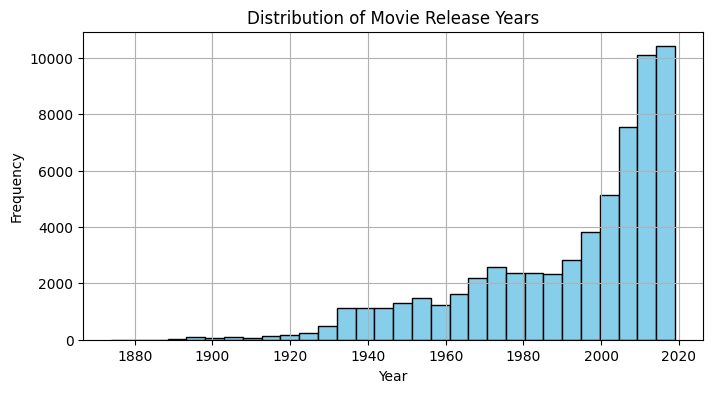

In [10]:
# Capture 4 digit year from the title and create a new column 'year'
movies['year'] = movies['title'].str.extract(r'\((\d{4})\)').astype('float')
print('Movies titles with parseable years:', movies['year'].count())

# Extract genres into a list and create a new column 'genres_list'
movies['genres_list'] = movies['genres'].str.split('|')
display(movies[['movieId', 'title', 'year', 'genres_list']].head())

if movies['year'].notna().any():
    ax = movies['year'].dropna().astype(int).hist(bins=30, color='skyblue', edgecolor='black')
    ax.set_title('Distribution of Movie Release Years')
    ax.set_xlabel('Year')
    ax.set_ylabel('Frequency')
    plt.show()

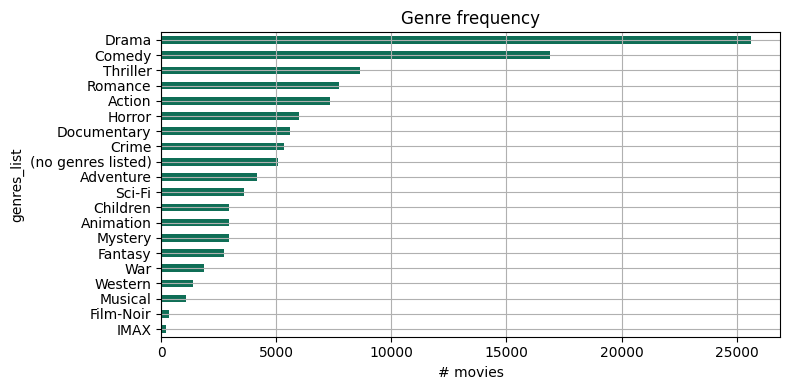

In [11]:
# Explode the genres_list to have one genre per row
genres_exploded = movies.explode('genres_list')

# Count the number of movies in each genre
genre_counts = genres_exploded['genres_list'].value_counts()

# Plot the distribution of movie genres
ax = genre_counts.plot(kind='barh', color='#0F6E56')
ax.invert_yaxis()
ax.set_title('Genre frequency')
ax.set_xlabel('# movies')
plt.tight_layout()
plt.show()

## Stage 7 - Time and Genre Exploration

This stage checks whether ratings change over time and whether some genres receive higher average ratings than others. These patterns help decide which side features may help the final model.

What was learned:
- Ratings can drift over time because user behavior and movie popularity change.
- Genre-level averages can capture broad taste patterns.
- Exploratory analysis should guide feature engineering, not just describe data.


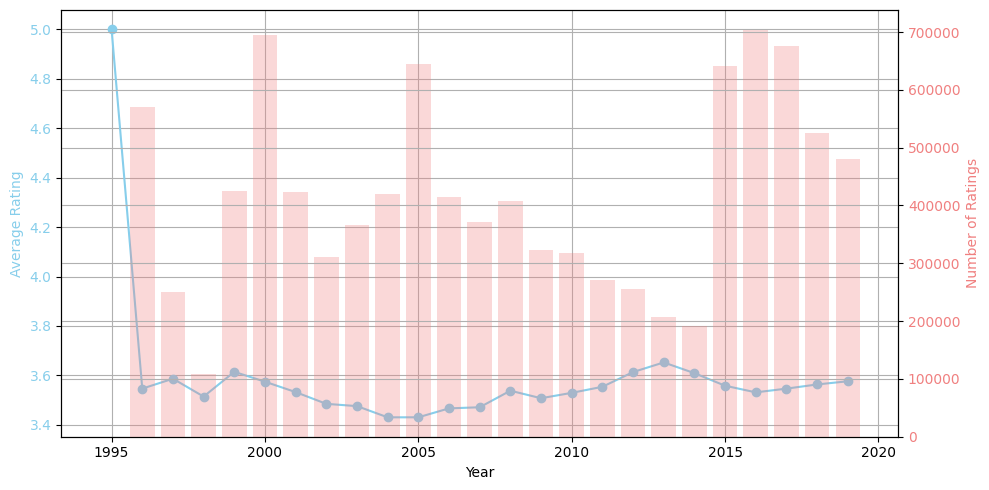

In [12]:
# Convert timestamp to pandas datetime
train['datetime'] = pd.to_datetime(train['timestamp'], unit='s')

# aggregate ratings by year and calculate the average rating for each year
by_year = train.set_index('datetime')['rating'].resample('YS').agg(['mean', 'count'])

# Plot the average rating by year
fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.plot(by_year.index.year, by_year['mean'], marker='o', color='skyblue')
ax1.set_xlabel('Year')
ax1.set_ylabel('Average Rating', color='skyblue')
ax1.tick_params(axis='y', labelcolor='skyblue')

ax2 = ax1.twinx()
ax2.bar(by_year.index.year, by_year['count'], alpha=0.3, color='lightcoral')
ax2.set_ylabel('Number of Ratings', color='lightcoral')
ax2.tick_params(axis='y', labelcolor='lightcoral')
plt.tight_layout()
plt.show()

In [13]:
# Merge train and movies datasets to analyze ratings by genre
train_genres = (train[['movieId', 'rating']]
                 .merge(movies[['movieId', 'genres_list']], on='movieId', how='left')
                 .explode('genres_list'))
# Calculate average rating and count of ratings for each genre
genre_rating = (train_genres.groupby('genres_list')['rating']
               .agg(['mean', 'count'])
               .sort_values(by='mean', ascending=False))

# Round mean ratings to 2 decimal places
genre_rating['mean'] = genre_rating['mean'].round(2)

# Display the average rating and count of ratings for each genre
display(genre_rating)

,mean,count
genres_list,,
Film-Noir,3.92,99186
War,3.79,506648
Documentary,3.71,128742
Crime,3.68,1674612
Drama,3.68,4384454
Mystery,3.67,805277
Animation,3.62,653001
IMAX,3.60,424834
Western,3.59,193496


## Stage 8 - Cold-Start and Submission Checks

The notebook checks whether the test set contains users or movies not seen in training and verifies the sample submission format.

What was learned:
- A deployed recommender needs safe fallbacks for unknown users or movies.
- Submission formatting is part of the modeling pipeline, not an afterthought.
- Models should clip predictions to the valid rating range.


In [14]:
# Convert users and movies to sets for faster lookup
users_set, movies_set = set(train['userId']), set(train['movieId'])

cold_users = set(test['userId']) - users_set
cold_movies = set(test['movieId']) - movies_set

# Print the number of cold users and cold movies in the test dataset
print(f'Number of cold users in test set: {len(cold_users)}')
print(f'Number of cold movies in test set: {len(cold_movies)}')

print(f'Percentage of cold users: {len(cold_users) / len(test["userId"].unique()):.2%}')
print(f'Percentage of cold movies: {len(cold_movies) / len(test["movieId"].unique()):.2%}')

print(f'Number of test ratings with cold users: {test["userId"].isin(cold_users).sum()} : {test["userId"].isin(cold_users).sum() / len(test):.2%}')
print(f'Number of test ratings with cold movies: {test["movieId"].isin(cold_movies).sum()} : {test["movieId"].isin(cold_movies).sum() / len(test):.2%}')

Number of cold users in test set: 0
Number of cold movies in test set: 5044
Percentage of cold users: 0.00%
Percentage of cold movies: 12.72%
Number of test ratings with cold users: 0 : 0.00%
Number of test ratings with cold movies: 6383 : 0.13%


## Stage 9 - Genome Tag Data

Genome tag scores describe movies using semantic tags such as animation, comedy, romance, or action-related concepts. The notebook filters this large file to relevant movies to reduce memory pressure.

What was learned:
- Content data can help when rating history is sparse.
- Large auxiliary files should be filtered before transformation.
- Movie embeddings can be built from tag relevance vectors.


In [15]:
# get relevant movies from train and test data only
relevant_movies = movies_set | set(test['movieId'])

# load genome_score
genome_path = DATA_DIR / "genome_scores.csv"

# Check if file exist
if genome_path.exists():
    # Load the genome scores dataset optimally by converting data to minimal datatype
    g_dtypes = {'movieId': 'int32', 'tagId': 'int16', 'relevance': 'float32'}
    chunks = []
    for chunk in pd.read_csv(genome_path, dtype=g_dtypes, chunksize=1_000_000):
        chunks.append(chunk[chunk['movieId'].isin(relevant_movies)])
    genome_scores = pd.concat(chunks, ignore_index=True)

    print('genome (filtered):', genome_scores.shape,
          '| %.1f MB' % (genome_scores.memory_usage(deep=True).sum() / 1e6))
    display(genome_scores.head())

    # load genome_tag dataset
    genome_tag = pd.read_csv(DATA_DIR / 'genome_tags.csv')

    # Most relevant tag for one example movie
    example_movie_id = 1
    example_genome_scores = genome_scores[genome_scores['movieId'] == example_movie_id]
    example_genome_tags = genome_tag[genome_tag['tagId'].isin(example_genome_scores['tagId'])]

    # Top genome_tag for example movie
    top_tags = (example_genome_scores
                .merge(example_genome_tags, on='tagId', how='left')
                .nlargest(10, 'relevance')[['tag', 'relevance']])
    print(f'Top tags for movieId {example_movie_id}:')
    print(top_tags)
else:
    print(f'Genome scores file not found at {genome_path}. Please ensure the file is in the data directory.')

genome (filtered): (15584448, 3) | 155.8 MB


,movieId,tagId,relevance
0,1,1,0.02875
1,1,2,0.02375
2,1,3,0.06250
3,1,4,0.07575
4,1,5,0.14075


Top tags for movieId 1:
                     tag  relevance
1035                toys    0.99925
243   computer animation    0.99875
785      pixar animation    0.99575
588      kids and family    0.98575
63             animation    0.98425
587                 kids    0.98000
784                pixar    0.96450
203             children    0.95975
185              cartoon    0.95475
62              animated    0.94725


## Stage 10 - Train/Validation Split

The training data is split into a training subset and validation subset. The validation set acts as unseen data for comparing models before creating Kaggle submissions.

What was learned:
- Honest validation is essential for measuring generalization.
- A model that performs well only on training data is not useful for recommendation.
- Keeping validation data separate helps avoid leakage.


In [16]:
# Split the train dataset into a training set and a validation set
tr, val = train_test_split(train, test_size=0.2, random_state=42)

print(f'Train set: {tr.shape}, Validation set: {val.shape}')

Train set: (8000030, 5), Validation set: (2000008, 5)


## Stage 11 - Global Mean Baseline

The first model predicts the same value for every user/movie pair: the average training rating. This is intentionally simple and provides a minimum benchmark.

What was learned:
- Every machine learning project needs a baseline.
- If a complex model cannot beat the global mean, the model is not learning useful structure.
- RMSE from the global mean gives context for later improvements.


In [17]:
# Calculate the global mean rating from the training set
global_mean = tr['rating'].mean()
print(f'Global mean rating: {global_mean:.4f}')

# Compute the predicted mean
pred_mean = np.full(len(val), global_mean)

# Calculate RMSE for the global mean model
rmse_mean = root_mean_squared_error(val['rating'], pred_mean)
print(f'Global mean model RMSE: {rmse_mean:.4f}')

Global mean rating: 3.5335
Global mean model RMSE: 1.0609


## Stage 12 - Regularized User and Movie Bias Model

The bias model learns that some users rate generally higher or lower than average, and some movies are generally liked or disliked. Regularization prevents users or movies with few ratings from getting extreme bias values.

What was learned:
- A strong recommender can start with simple user and item effects.
- Regularization is important when data is sparse or unevenly distributed.
- Bias models provide strong baselines and useful features for later stacked models.


In [18]:
# Define a function to compute regularized movie and user biases from rating frame
def fit_biases(df, mu, reg_i=10.0, reg_u=10.0, n_iter=5):
    """
    Compute regularized movie and user biases.

    Model:
        predicted_rating = global_mean + movie_bias + user_bias
    """

    b_i = pd.Series(0.0, index=df['movieId'].unique())
    b_u = pd.Series(0.0, index=df['userId'].unique())

    for _ in range(n_iter):
        # Update movie bias after removing global mean and user bias
        movie_residual = (
            df['rating']
            - mu
            - df['userId'].map(b_u).fillna(0.0)
        )

        agg_i = movie_residual.groupby(df['movieId']).agg(['sum', 'count'])
        b_i = agg_i['sum'] / (reg_i + agg_i['count'])

        # Update user bias after removing global mean and movie bias
        user_residual = (
            df['rating']
            - mu
            - df['movieId'].map(b_i).fillna(0.0)
        )

        agg_u = user_residual.groupby(df['userId']).agg(['sum', 'count'])
        b_u = agg_u['sum'] / (reg_u + agg_u['count'])

    return b_i, b_u


def predict_bias_model(df, mu, b_i, b_u):
    pred = (
        mu
        + df['movieId'].map(b_i).fillna(0.0)
        + df['userId'].map(b_u).fillna(0.0)
    )

    return pred.clip(0.5, 5.0)

In [19]:
# Build only movie bias model
b_i, _ = fit_biases(tr, global_mean, reg_u=0.0)
# Predict ratings for the validation set using the movie bias model
pred_movie = predict_bias_model(val, global_mean, b_i, pd.Series(0.0))

# Build full bias model with both movie and user bias
b_i, b_u = fit_biases(tr, global_mean, reg_i=10.0, reg_u=10.0)
# Predict ratings for the validation set using the full bias model
pred_full = predict_bias_model(val, global_mean, b_i, b_u)

# Print RMSE for both models
rmse_movie = root_mean_squared_error(val['rating'], pred_movie)
rmse_full = root_mean_squared_error(val['rating'], pred_full)

print(f'Movie bias model RMSE: {rmse_movie:.4f}')
print(f'Full bias model RMSE: {rmse_full:.4f}')

Movie bias model RMSE: 0.9634
Full bias model RMSE: 0.8655


In [20]:
results = []
for reg in [1, 5, 10, 15, 20, 25, 30]:
    bi, bu = fit_biases(tr, global_mean, reg_i=reg, reg_u=reg)
    val_rmse = root_mean_squared_error(val['rating'], predict_bias_model(val, global_mean, bi, bu))
    results.append((reg, val_rmse))

res = pd.DataFrame(results, columns=['lambda', 'val_rmse']).set_index('lambda')

display(res)
best_lambda = res['val_rmse'].idxmin()
print('Best lambda:', best_lambda, '-> RMSE', round(res.loc[best_lambda, 'val_rmse'], 4))

,val_rmse
lambda,
1,0.864912
5,0.864088
10,0.865482
15,0.867417
20,0.869457
25,0.871480
30,0.873443


Best lambda: 5 -> RMSE 0.8641


In [21]:
b_i, b_u = fit_biases(tr, global_mean, reg_i=best_lambda, reg_u=best_lambda)
rmse_tuned = root_mean_squared_error(val['rating'], predict_bias_model(val, global_mean, b_i, b_u))
print(f'Tuned bias model RMSE: {rmse_tuned:.4f}')

Tuned bias model RMSE: 0.8641


In [22]:
# Demonstrate a fake unseen movieId for a real userId from the validation set
demo_user = tr['userId'].iloc[0]
demo_df = pd.DataFrame({'userId': [demo_user], 'movieId': [10**9]})  # 10**9 is a fake movieId

# Predict and print
pred_demo = predict_bias_model(demo_df, global_mean, b_i, b_u)
print(f'Predicted rating for userId {demo_user} and unseen movieId 10**9: {pred_demo.iloc[0]:.4f}')

Predicted rating for userId 8062 and unseen movieId 10**9: 3.4535


In [23]:
# compute the global mean from ALL labeled ratings
full_mean = train['rating'].mean()

# fit the bias model on the full training data with the best lambda
b_i_full, b_u_full = fit_biases(train, full_mean, reg_i=best_lambda, reg_u=best_lambda)

test_pred = predict_bias_model(test, full_mean, b_i_full, b_u_full)

# Create submission file as a pandas dataframe
submission = pd.DataFrame({
    'Id': test['userId'].astype(str) + '_' + test['movieId'].astype(str),
    'rating': test_pred
})

# Save the submission file to a CSV
output_path = OUTPUT_DIR / 'submission_bias_baseline.csv'
submission.to_csv(output_path, index=False)
print(f'Wrote {output_path} with shape {submission.shape} and size %.1f MB' % (output_path.stat().st_size / 1e6))
submission.head()

Wrote /kaggle/working/submission_bias_baseline.csv with shape (5000019, 2) and size 148.7 MB


,Id,rating
0,1_2011,3.468662
1,1_4144,4.111833
2,1_5767,3.553377
3,1_6711,3.757863
4,1_7318,3.113994


## Stage 13 - Matrix Factorization Preparation

Before training SVD-style models, user and movie IDs are mapped to contiguous integer indices. This makes vectorized and Numba-accelerated matrix operations possible.

What was learned:
- Raw IDs are identifiers, not array positions.
- Efficient recommenders often require remapping sparse IDs into dense index spaces.
- Matrix factorization represents users and movies as latent vectors.


In [24]:
mu = global_mean
mu

np.float32(3.533469)

In [25]:
u_cat = tr['userId'].astype('category')
i_cat = tr['movieId'].astype('category')

user_map = {uid: code for code, uid in enumerate(u_cat.cat.categories)}
item_map = {iid: code for code, iid in enumerate(i_cat.cat.categories)}

u_arr = u_cat.cat.codes.values.astype(np.int32)
i_arr = i_cat.cat.codes.values.astype(np.int32)
r_arr = tr['rating'].values.astype(np.float64)
n_users, n_items = len(user_map), len(item_map)
print(f'{n_users:,} users  x  {n_items:,} movies  ({len(r_arr):,} ratings)')

162,538 users  x  45,438 movies  (8,000,030 ratings)


## Stage 14 - Custom SVD with Numba-Accelerated SGD

This stage implements a matrix factorization model from scratch. The model learns user factors, movie factors, and bias terms using stochastic gradient descent.

What was learned:
- Matrix factorization captures hidden taste dimensions that are not directly visible in genres.
- Numba can make Python loops fast enough for large-scale training.
- Learning rate, regularization, and early stopping strongly affect recommender performance.


In [26]:
@njit(cache=True)
def train_sgd(u_arr, i_arr, r_arr, bu, bi, P, Q, mu, n_epochs, lr, reg, seed):
    np.random.seed(seed)
    n, k = u_arr.shape[0], P.shape[1]
    for epoch in range(n_epochs):
        order = np.random.permutation(n)          # shuffle each epoch
        for t in range(n):
            row = order[t]
            u, i = u_arr[row], i_arr[row]
            dot = 0.0
            for f in range(k):
                dot += P[u, f] * Q[i, f]
            e = r_arr[row] - (mu + bu[u] + bi[i] + dot)   # prediction error
            bu[u] += lr * (e - reg * bu[u])
            bi[i] += lr * (e - reg * bi[i])
            for f in range(k):
                puf, qif = P[u, f], Q[i, f]
                P[u, f] += lr * (e * qif - reg * puf)
                Q[i, f] += lr * (e * puf - reg * qif)

In [27]:
K, LR, REG = 50, 0.005, 0.02
MAX_EPOCHS, LR_DECAY, PATIENCE, BLOCK = 60, 0.95, 3, 4   # train longer; decay lr each block; stop if val RMSE stalls

rng = np.random.default_rng(0)
bu = np.zeros(n_users); bi = np.zeros(n_items)
P  = rng.normal(0, 0.1, (n_users, K))
Q  = rng.normal(0, 0.1, (n_items, K))

def predict(user_ids, movie_ids):
    uc = pd.Series(user_ids).map(user_map).fillna(-1).astype(int).values
    ic = pd.Series(movie_ids).map(item_map).fillna(-1).astype(int).values
    pred = np.full(len(uc), mu)
    hu, hi = uc >= 0, ic >= 0
    pred[hu] += bu[uc[hu]]
    pred[hi] += bi[ic[hi]]
    both = hu & hi
    pred[both] += np.einsum('ij,ij->i', P[uc[both]], Q[ic[both]])
    return np.clip(pred, 0.5, 5.0)

def rmse(y, p): return float(np.sqrt(np.mean((np.asarray(y) - np.asarray(p)) ** 2)))

lr = LR
best_rmse, best_state, bad_blocks = np.inf, None, 0
for block in range(MAX_EPOCHS // BLOCK):
    train_sgd(u_arr, i_arr, r_arr, bu, bi, P, Q, mu, BLOCK, lr, REG, seed=block)
    rv = rmse(val['rating'], predict(val['userId'].values, val['movieId'].values))
    print(f'after {(block+1)*BLOCK:3d} epochs   lr={lr:.5f}   val RMSE = {rv:.4f}')
    if rv < best_rmse - 1e-5:
        best_rmse, best_state, bad_blocks = rv, (bu.copy(), bi.copy(), P.copy(), Q.copy()), 0
    else:
        bad_blocks += 1
        if bad_blocks >= PATIENCE:
            print(f'No improvement for {PATIENCE} blocks, stopping early.')
            break
    lr *= LR_DECAY

bu, bi, P, Q = best_state   # roll back to the best-scoring checkpoint, not necessarily the last one
print(f'Best val RMSE: {best_rmse:.4f}')

after   4 epochs   lr=0.00500   val RMSE = 0.8757
after   8 epochs   lr=0.00475   val RMSE = 0.8638
after  12 epochs   lr=0.00451   val RMSE = 0.8496
after  16 epochs   lr=0.00429   val RMSE = 0.8391
after  20 epochs   lr=0.00407   val RMSE = 0.8321
after  24 epochs   lr=0.00387   val RMSE = 0.8284
after  28 epochs   lr=0.00368   val RMSE = 0.8271
after  32 epochs   lr=0.00349   val RMSE = 0.8271
after  36 epochs   lr=0.00332   val RMSE = 0.8279
after  40 epochs   lr=0.00315   val RMSE = 0.8290
No improvement for 3 blocks, stopping early.
Best val RMSE: 0.8271


In [28]:
# Predict test ratings
preds = predict(
    test["userId"].values,
    test["movieId"].values
)

# Create submission file
submission = pd.DataFrame({
    "Id": test["userId"].astype(str) + "_" + test["movieId"].astype(str),
    "rating": preds
})

# Save CSV
out = OUTPUT_DIR / "submission_scratch_svd.csv"
submission.to_csv(out, index=False)

print("Wrote:", out)
print("Rows:", len(submission))

display(submission.head())

Wrote: /kaggle/working/submission_scratch_svd.csv
Rows: 5000019


,Id,rating
0,1_2011,3.519387
1,1_4144,4.175992
2,1_5767,4.044947
3,1_6711,3.834632
4,1_7318,3.394142


## Stage 15 - Multiple SVD Configurations

Several SVD configurations are trained with different factor sizes and regularization settings. Their validation RMSE scores are compared to identify stronger models.

What was learned:
- Hyperparameters change model quality significantly.
- More latent factors are not always better; they can overfit or become unstable.
- Comparing models on the same validation split creates a fair evaluation.


In [29]:
base_configs = {
    "SVD_50":  {"K": 50,  "LR": 0.005, "REG": 0.02, "MAX_EPOCHS": 60},
    "SVD_80":  {"K": 80,  "LR": 0.005, "REG": 0.05, "MAX_EPOCHS": 60},
    "SVD_100": {"K": 100, "LR": 0.002, "REG": 0.05, "MAX_EPOCHS": 60},
}

In [30]:
def fit_svd_model(K, LR, REG, MAX_EPOCHS, val_users, val_movies, val_ratings,
                   seed=0, lr_decay=0.95, patience=3, block=4):
    rng = np.random.default_rng(seed)

    bu = np.zeros(n_users, dtype=np.float64)
    bi = np.zeros(n_items, dtype=np.float64)
    P = rng.normal(0, 0.1, (n_users, K)).astype(np.float64)
    Q = rng.normal(0, 0.1, (n_items, K)).astype(np.float64)

    lr = LR
    best_rmse, best_state, bad_blocks = np.inf, None, 0
    for b in range(MAX_EPOCHS // block):
        train_sgd(u_arr, i_arr, r_arr, bu, bi, P, Q, mu, block, lr, REG, seed=seed * 1000 + b)
        preds = predict_svd(val_users, val_movies, bu, bi, P, Q)
        rv = rmse(val_ratings, preds)
        if rv < best_rmse - 1e-5:
            best_rmse, best_state, bad_blocks = rv, (bu.copy(), bi.copy(), P.copy(), Q.copy()), 0
        else:
            bad_blocks += 1
            if bad_blocks >= patience:
                break
        lr *= lr_decay

    return best_state, best_rmse


def predict_svd(user_ids, movie_ids, bu, bi, P, Q):
    uc = pd.Series(user_ids).map(user_map).fillna(-1).astype(np.int64).values
    ic = pd.Series(movie_ids).map(item_map).fillna(-1).astype(np.int64).values

    pred = np.full(len(uc), mu, dtype=np.float64)

    hu = uc >= 0
    hi = ic >= 0

    pred[hu] += bu[uc[hu]]
    pred[hi] += bi[ic[hi]]

    both = hu & hi

    pred[both] += np.sum(
        P[uc[both]] * Q[ic[both]],
        axis=1
    )

    return np.clip(pred, 0.5, 5.0)

In [31]:
val_pred = {}
models = {}
results = []

for name, cfg in base_configs.items():
    (bu_, bi_, P_, Q_), score = fit_svd_model(
        K=cfg["K"],
        LR=cfg["LR"],
        REG=cfg["REG"],
        MAX_EPOCHS=cfg["MAX_EPOCHS"],
        val_users=val["userId"].values,
        val_movies=val["movieId"].values,
        val_ratings=val["rating"].values,
        seed=42
    )

    preds = predict_svd(
        val["userId"].values,
        val["movieId"].values,
        bu_, bi_, P_, Q_
    )

    val_pred[name] = preds
    models[name] = (bu_, bi_, P_, Q_)

    results.append({
        "model": name,
        **cfg,
        "RMSE": score
    })

    print(f"{name:8s} validation RMSE: {score:.4f}")

SVD_50   validation RMSE: 0.8271
SVD_80   validation RMSE: 0.8150
SVD_100  validation RMSE: 0.8442


In [32]:
results_df = pd.DataFrame(results).sort_values("RMSE")
display(results_df)

,model,K,LR,REG,MAX_EPOCHS,RMSE
1,SVD_80,80,0.005,0.05,60,0.814982
0,SVD_50,50,0.005,0.02,60,0.827061
2,SVD_100,100,0.002,0.05,60,0.844192


## Stage 16 - Optimized Ensemble of SVD Models

The predictions from multiple SVD models are blended using optimized non-negative weights. This combines useful signals from different models while limiting weak models.

What was learned:
- Ensembles often outperform single models because different models make different errors.
- Weight optimization can improve over a simple average.
- Validation predictions can be used to learn blend weights safely.


In [33]:
names = list(val_pred.keys())
M = np.column_stack([val_pred[n] for n in names])   # shape (n_val, n_models)
y_val = val['rating'].values

def blended_rmse(weights, preds_matrix, y):
    return np.sqrt(np.mean((preds_matrix @ weights - y) ** 2))

# (a) equal-weight average, as a baseline for the optimizer to beat
equal_w = np.ones(len(names)) / len(names)
print('Equal-weight blend RMSE :', round(blended_rmse(equal_w, M, y_val), 4))

# (b) optimised non-negative weights that sum to 1
blend_res = minimize(blended_rmse, equal_w, args=(M, y_val),
                      method='SLSQP', bounds=[(0, 1)] * len(names),
                      constraints=({'type': 'eq', 'fun': lambda w: w.sum() - 1},))
opt_w = blend_res.x
print('Optimised weights       :', dict(zip(names, opt_w.round(3))))

ensemble_pred = M @ opt_w
ensemble_rmse = blend_res.fun
print('Ensemble RMSE:', ensemble_rmse)

Equal-weight blend RMSE : 0.8191
Optimised weights       : {'SVD_50': np.float64(0.28), 'SVD_80': np.float64(0.72), 'SVD_100': np.float64(0.0)}
Ensemble RMSE: 0.8128049963253138


In [34]:
test_base_preds = {name: predict_svd(test["userId"].values, test["movieId"].values, *models[name])
                    for name in names}

T = np.column_stack([test_base_preds[n] for n in names])
blended = np.clip(T @ opt_w, 0.5, 5.0)

submission = pd.DataFrame({
    "Id": test["userId"].astype(str) + "_" + test["movieId"].astype(str),
    "rating": blended,
})

out = OUTPUT_DIR / "submission_optimized_ensemble.csv"
submission.to_csv(out, index=False)

print("Wrote:", out)
display(submission.head())

Wrote: /kaggle/working/submission_optimized_ensemble.csv


,Id,rating
0,1_2011,3.677420
1,1_4144,4.018857
2,1_5767,3.742719
3,1_6711,3.956523
4,1_7318,3.539159


In [35]:
best_name = results_df.iloc[0]["model"]
bu_best, bi_best, P_best, Q_best = models[best_name]

test_preds = predict_svd(
    test["userId"].values,
    test["movieId"].values,
    bu_best, bi_best, P_best, Q_best
)

submission = pd.DataFrame({
    "Id": test["userId"].astype(str) + "_" + test["movieId"].astype(str),
    "rating": test_preds
})

out = OUTPUT_DIR / "submission_best_svd.csv"
submission.to_csv(out, index=False)

print("Wrote:", out, "| best config:", best_name)
display(submission.head())

Wrote: /kaggle/working/submission_best_svd.csv | best config: SVD_80


,Id,rating
0,1_2011,3.788620
1,1_4144,4.059815
2,1_5767,3.765251
3,1_6711,3.900930
4,1_7318,3.496176


## Stage 17 - Content-Based Hybrid Using Genome Tags

The genome tag matrix is compressed with TruncatedSVD to create dense movie content vectors. User profiles are built from movies they liked, then content scores are calibrated and blended with collaborative predictions.

What was learned:
- Collaborative filtering learns from user behavior, while content filtering learns from item descriptions.
- Content models are useful for niche or cold-start movies, but may be weaker alone.
- A small content contribution can still improve a strong collaborative model.


In [36]:
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import normalize

In [37]:
movie_tag = genome_scores.pivot(
    index="movieId",
    columns="tagId",
    values="relevance"
).fillna(0)

In [38]:
N_COMPONENTS = 50

tag_svd = TruncatedSVD(
    n_components=N_COMPONENTS,
    random_state=42
)

movie_content = tag_svd.fit_transform(movie_tag)

movie_content = normalize(movie_content)

In [39]:
# Look it up
content_movie_ids = movie_tag.index.values

movie_content_map = {
    movie_id: idx
    for idx, movie_id in enumerate(content_movie_ids)
}

In [40]:
# user test profile
user_mean = train.groupby("userId")["rating"].mean()

In [41]:
# Now create user profiles from movies rated above the user’s average:

user_profiles = {}

for user_id, group in train.groupby("userId"):
    baseline = user_mean.loc[user_id]

    liked = group[group["rating"] > baseline]

    vectors = []

    for movie_id in liked["movieId"]:
        if movie_id in movie_content_map:
            idx = movie_content_map[movie_id]
            vectors.append(movie_content[idx])

    if len(vectors) > 0:
        profile = np.mean(vectors, axis=0)
        user_profiles[user_id] = profile / (np.linalg.norm(profile) + 1e-9)

In [42]:
# Predict content similarity score
def content_score(user_ids, movie_ids):
    scores = np.zeros(len(user_ids), dtype=np.float64)

    for idx, (u, m) in enumerate(zip(user_ids, movie_ids)):
        if u in user_profiles and m in movie_content_map:
            movie_vec = movie_content[movie_content_map[m]]
            user_vec = user_profiles[u]

            scores[idx] = np.dot(user_vec, movie_vec)
        else:
            scores[idx] = 0.0

    return scores

In [43]:
# Calibrate content score to rating scale

# Content similarity is not yet rating. Convert it to rating-like values using validation data.

val_content_raw = content_score(
    val["userId"].values,
    val["movieId"].values
)

val_svd_pred = predict(
    val["userId"].values,
    val["movieId"].values
)

In [44]:
# Fit simple linear calibration:

from sklearn.linear_model import LinearRegression

calibrator = LinearRegression()

calibrator.fit(
    val_content_raw.reshape(-1, 1),
    val["rating"].values
)

val_content_pred = calibrator.predict(
    val_content_raw.reshape(-1, 1)
)

val_content_pred = np.clip(val_content_pred, 0.5, 5.0)

In [45]:
print("Content RMSE:", rmse(val["rating"].values, val_content_pred))
print("SVD RMSE:", rmse(val["rating"].values, val_svd_pred))

Content RMSE: 1.0304348307628985
SVD RMSE: 0.8271097540855408


In [46]:
# Blend SVD + content model

# Try different blend weights:

blend_results = []

for alpha in np.arange(0.0, 1.05, 0.05):
    hybrid_pred = (
        alpha * val_svd_pred
        + (1 - alpha) * val_content_pred
    )

    score = rmse(val["rating"].values, hybrid_pred)

    blend_results.append({
        "alpha_svd": alpha,
        "alpha_content": 1 - alpha,
        "RMSE": score
    })

blend_df = pd.DataFrame(blend_results).sort_values("RMSE")
display(blend_df.head(10))

,alpha_svd,alpha_content,RMSE
19,0.95,0.05,0.825987
18,0.90,0.10,0.826185
20,1.00,0.00,0.827110
17,0.85,0.15,0.827703
16,0.80,0.20,0.830534
15,0.75,0.25,0.834663
14,0.70,0.30,0.840073
13,0.65,0.35,0.846739
12,0.60,0.40,0.854630
11,0.55,0.45,0.863714


In [47]:
best_alpha = blend_df.iloc[0]["alpha_svd"]

test_svd_pred = predict(
    test["userId"].values,
    test["movieId"].values
)

test_content_raw = content_score(
    test["userId"].values,
    test["movieId"].values
)

test_content_pred = calibrator.predict(
    test_content_raw.reshape(-1, 1)
)

test_content_pred = np.clip(test_content_pred, 0.5, 5.0)

test_hybrid_pred = (
    best_alpha * test_svd_pred
    + (1 - best_alpha) * test_content_pred
)

test_hybrid_pred = np.clip(test_hybrid_pred, 0.5, 5.0)

In [48]:
submission = pd.DataFrame({
    "Id": test["userId"].astype(str) + "_" + test["movieId"].astype(str),
    "rating": test_hybrid_pred
})

out = OUTPUT_DIR / "submission_hybrid_svd_content.csv"
submission.to_csv(out, index=False)

print("Wrote:", out)
display(submission.head())

Wrote: /kaggle/working/submission_hybrid_svd_content.csv


,Id,rating
0,1_2011,3.496263
1,1_4144,4.152538
2,1_5767,4.031101
3,1_6711,3.831802
4,1_7318,3.389235


## Stage 18 - GBM Stacking Model

The final model uses LightGBM to stack all earlier signals: bias predictions, SVD predictions, optimized ensemble predictions, content scores, and side features such as movie popularity, user activity, release year, and genre averages.

The validation set is split again into `val_a` and `val_b` so the stacker can be trained and evaluated without grading on the same rows it learned from.

What was learned:
- Stacking lets a model learn when to trust each base predictor.
- Tree-based models can capture non-linear relationships between popularity, content, and collaborative signals.
- Leakage control is critical when using predictions from earlier models as features.


In [49]:
import lightgbm as lgb

# fit on `tr` only (not `train`) - `val` rows must stay unseen by every feature the stacker
# uses, or movie_mean/user_mean would leak each row's own rating right back into its features
movie_mean_map      = tr.groupby('movieId')['rating'].mean()
user_mean_tr         = tr.groupby('userId')['rating'].mean()
movie_n_ratings_map = tr.groupby('movieId').size()
user_n_ratings_map  = tr.groupby('userId').size()
movie_year_map      = movies.set_index('movieId')['year']
year_fill           = movie_year_map.median()

# average rating of each movie's genres, from the Part-1 EDA `genre_rating` table - a coarse,
# genre-level aggregate over thousands of movies each, so any one row's leakage here is negligible
movie_genre_avg = (
    movies[['movieId', 'genres_list']]
    .explode('genres_list')
    .merge(genre_rating['mean'].rename('genre_mean'), left_on='genres_list', right_index=True, how='left')
    .groupby('movieId')['genre_mean'].mean()
)

def popularity_features(df):
    feats = pd.DataFrame(index=df.index)
    feats['movie_mean']      = df['movieId'].map(movie_mean_map).fillna(global_mean).values
    feats['user_mean']       = df['userId'].map(user_mean_tr).fillna(global_mean).values
    feats['movie_n_ratings'] = np.log1p(df['movieId'].map(movie_n_ratings_map).fillna(0)).values
    feats['user_n_ratings']  = np.log1p(df['userId'].map(user_n_ratings_map).fillna(0)).values
    feats['movie_year']      = df['movieId'].map(movie_year_map).fillna(year_fill).values
    feats['genre_avg']       = df['movieId'].map(movie_genre_avg).fillna(global_mean).values
    return feats

def stack_features(df, bias_pred, svd_pred, ensemble_pred_arr, content_raw, content_pred):
    feats = popularity_features(df)
    feats['bias_pred']     = bias_pred
    feats['svd_pred']      = svd_pred
    feats['ensemble_pred'] = ensemble_pred_arr
    feats['content_raw']   = content_raw
    feats['content_pred']  = content_pred
    return feats

In [50]:
val_bias_pred = predict_bias_model(val, global_mean, b_i, b_u)

split = len(val) // 2
val_a, val_b = val.iloc[:split], val.iloc[split:]

X_val_a = stack_features(val_a, val_bias_pred.values[:split], val_svd_pred[:split], ensemble_pred[:split],
                          val_content_raw[:split], val_content_pred[:split])
X_val_b = stack_features(val_b, val_bias_pred.values[split:], val_svd_pred[split:], ensemble_pred[split:],
                          val_content_raw[split:], val_content_pred[split:])
y_val_a, y_val_b = val_a['rating'].values, val_b['rating'].values

print('Stacker train (val_a):', X_val_a.shape, '| Stacker eval (val_b):', X_val_b.shape)

Stacker train (val_a): (1000004, 11) | Stacker eval (val_b): (1000004, 11)


In [51]:
lgb_params = {
    'objective': 'regression',
    'metric': 'rmse',
    'learning_rate': 0.05,
    'num_leaves': 31,
    'min_data_in_leaf': 200,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 1,
    'verbose': -1,
}

stacker = lgb.train(
    lgb_params,
    lgb.Dataset(X_val_a, label=y_val_a),
    num_boost_round=8000,
    valid_sets=[lgb.Dataset(X_val_b, label=y_val_b)],
    callbacks=[lgb.early_stopping(stopping_rounds=100, verbose=False)],
)

stack_pred_b = np.clip(stacker.predict(X_val_b, num_iteration=stacker.best_iteration), 0.5, 5.0)
print('Stacked GBM RMSE on held-out val_b:', round(rmse(y_val_b, stack_pred_b), 4))
print('Best iteration:', stacker.best_iteration, '/ 8000')

display(pd.DataFrame({'feature': X_val_a.columns, 'gain': stacker.feature_importance('gain')})
        .sort_values('gain', ascending=False))

Stacked GBM RMSE on held-out val_b: 0.7851
Best iteration: 3195 / 8000


,feature,gain
8,ensemble_pred,3.283749e+06
7,svd_pred,4.352245e+05
6,bias_pred,2.319865e+05
9,content_raw,1.397634e+05
3,user_n_ratings,1.166861e+05
10,content_pred,9.968601e+04
0,movie_mean,6.674300e+04
1,user_mean,6.044110e+04
2,movie_n_ratings,5.655545e+04
5,genre_avg,4.164303e+04


In [52]:
X_val_full = stack_features(val, val_bias_pred.values, val_svd_pred, ensemble_pred,
                             val_content_raw, val_content_pred)
y_val_full = val['rating'].values

final_stacker = lgb.train(
    lgb_params,
    lgb.Dataset(X_val_full, label=y_val_full),
    num_boost_round=stacker.best_iteration,
)

test_bias_pred = predict_bias_model(test, global_mean, b_i, b_u)
X_test = stack_features(test, test_bias_pred.values, test_svd_pred, blended,
                         test_content_raw, test_content_pred)

test_stack_pred = np.clip(final_stacker.predict(X_test), 0.5, 5.0)

submission = pd.DataFrame({
    "Id": test["userId"].astype(str) + "_" + test["movieId"].astype(str),
    "rating": test_stack_pred,
})
out = OUTPUT_DIR / "submission_gbm_stack.csv"
submission.to_csv(out, index=False)

print("Wrote:", out, "|", len(submission), "rows")
display(submission.head())

Wrote: /kaggle/working/submission_gbm_stack.csv | 5000019 rows


,Id,rating
0,1_2011,2.975766
1,1_4144,4.155691
2,1_5767,4.165343
3,1_6711,4.410206
4,1_7318,3.137553


## Stage 19 - Final Model Comparison

This stage compares all major approaches using RMSE. The progression shows how each modeling stage improves over the previous one, ending with the GBM stacker as the strongest validation model.

What was learned:
- Model quality improved step by step from simple baselines to stacked learning.
- The GBM stacker achieved the best validation score because it combined multiple kinds of evidence.
- A clear comparison table is essential for explaining why the final model was selected.


In [53]:
models_to_check = {
    "global_mean":        pred_mean,
    "bias_baseline":      val_bias_pred.values,
    "scratch_svd":        val_svd_pred,
    "ensemble_optimized": ensemble_pred,
    "content_only":       val_content_pred,
    "svd_content_hybrid": best_alpha * val_svd_pred + (1 - best_alpha) * val_content_pred,
}

for name, preds in models_to_check.items():
    print(f'{name:20s} RMSE: {rmse(val["rating"].values, preds):.4f}')

# stacker is graded on val_b only - the one split it never trained on
print(f'{"gbm_stack (val_b only)":20s} RMSE: {rmse(y_val_b, stack_pred_b):.4f}')

global_mean          RMSE: 1.0609
bias_baseline        RMSE: 0.8641
scratch_svd          RMSE: 0.8271
ensemble_optimized   RMSE: 0.8128
content_only         RMSE: 1.0304
svd_content_hybrid   RMSE: 0.8260
gbm_stack (val_b only) RMSE: 0.7851


## Stage 20 - Saving the Deployment Bundle

The final cell packages the trained artifacts needed for Streamlit deployment. This includes the stacker, SVD models, blend weights, content model assets, feature maps, movie metadata, and version metadata.

What was learned:
- Deployment requires saving more than just the final estimator.
- The app must recreate exactly the same features used during training.
- Version metadata helps diagnose future loading or compatibility issues.


In [ ]:
import joblib
import sys
import sklearn
import lightgbm
import numpy
import pandas

deploy_bundle = {
    "global_mean": global_mean,
    "best_lambda": best_lambda,

    "movie_bias": b_i,
    "user_bias": b_u,

    "user_map": user_map,
    "item_map": item_map,

    "svd_models": models,
    "svd_model_names": names,
    "ensemble_weights": opt_w,

    "best_alpha": best_alpha,
    "calibrator": calibrator,
    "movie_content": movie_content,
    "movie_content_map": movie_content_map,
    "user_profiles": user_profiles,

    "stacker": final_stacker,
    "stacker_feature_columns": X_test.columns.tolist(),

    "movie_mean_map": movie_mean_map,
    "user_mean_tr": user_mean_tr,
    "movie_n_ratings_map": movie_n_ratings_map,
    "user_n_ratings_map": user_n_ratings_map,
    "movie_year_map": movie_year_map,
    "movie_genre_avg": movie_genre_avg,
    "year_fill": year_fill,

    "movies": movies[["movieId", "title", "genres", "year", "genres_list"]],

    "metadata": {
        "python": sys.version,
        "sklearn": sklearn.__version__,
        "lightgbm": lightgbm.__version__,
        "numpy": numpy.__version__,
        "pandas": pandas.__version__,
    }
}

joblib.dump(
    deploy_bundle,
    "/kaggle/working/movie_recommender_deploy_bundle.joblib",
    compress=3
)